## DROID Dataset Hacking
- Extract language instructions / prompts from the dataset
- Render session visualizations (cameras + control signals + metadata)

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation, FFMpegWriter
from tqdm import tqdm
import json
import cv2

In [3]:
# Install tensorflow-datasets if not present (tensorflow itself should already be installed)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'tensorflow-datasets', '-q'], check=True)

import tensorflow as tf
import tensorflow_datasets as tfds
print('TF:', tf.__version__, '  TFDS:', tfds.__version__)

TF: 2.20.0   TFDS: 4.9.9


In [4]:
# Paths relative to the vla folder
DROID_DIR = 'droid_100'
SAVE_DIR = 'droid_renders'
os.makedirs(SAVE_DIR, exist_ok=True)

## Part 1: Extract All Language Instructions

We skip image decoding to make this fast — only read text fields.

In [4]:
# builder_from_directory needs the versioned subdirectory (where dataset_info.json lives)
builder = tfds.builder_from_directory('droid_100/1.0.0')
print('Dataset name:', builder.name)
print('Version:', builder.version)
print('Splits:', builder.info.splits)

skip_images = {
    'steps': {
        'observation': {
            'exterior_image_1_left': tfds.decode.SkipDecoding(),
            'exterior_image_2_left': tfds.decode.SkipDecoding(),
            'wrist_image_left':      tfds.decode.SkipDecoding(),
        }
    }
}

ds = builder.as_dataset(split='train', decoders=skip_images)
print('Dataset loaded.')

Dataset name: r2d2_faceblur
Version: 1.0.0
Splits: {'train': <SplitInfo num_examples=100, num_shards=31>}
Dataset loaded.


In [ ]:
# language_instruction is the same every step, so grab it from the first step
# Use tf.data.experimental.cardinality for step count (avoids iterating all steps)
instructions = []

for episode in tqdm(ds):
    first_step = next(iter(episode['steps']))
    lang  = first_step['language_instruction'].numpy().decode('utf-8')
    lang2 = first_step['language_instruction_2'].numpy().decode('utf-8')
    lang3 = first_step['language_instruction_3'].numpy().decode('utf-8')

    n_steps = tf.data.experimental.cardinality(episode['steps']).numpy()
    file_path = episode['episode_metadata']['file_path'].numpy().decode('utf-8')

    instructions.append({
        'language_instruction':   lang,
        'language_instruction_2': lang2,
        'language_instruction_3': lang3,
        'file_path': file_path,
        'num_steps': int(n_steps),
    })

print(f'Extracted {len(instructions)} episodes')

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
# Save to JSON
with open(os.path.join(SAVE_DIR, 'language_instructions.json'), 'w') as f:
    json.dump(instructions, f, indent=2)
print('Saved language_instructions.json')

Saved language_instructions.json


In [ ]:
# Unique instructions overview
unique_lang1 = sorted(set(ep['language_instruction'] for ep in instructions if ep['language_instruction']))
print(f'Unique language_instruction values: {len(unique_lang1)}')
for inst in unique_lang1[:30]:
    print(' -', repr(inst))

Unique language_instruction values: 46
 - 'Close the drawer'
 - 'Get the marker from the table and place it in the colorless cup'
 - 'Move the cup to the right'
 - 'Move the faucet to the center of the sink'
 - 'Move the glass to the second row in the dishwasher'
 - 'Move the green plush to the left'
 - 'Move the orange objects from the pullout table to the desk'
 - 'Move the pan to the right.'
 - 'Move the pot to the top left corner of the table'
 - 'Move the sharpie to the table'
 - 'Move the vaseline closer to the mirror'
 - 'Move the yellow mug forward'
 - 'Pick the two bottles on the stove and place them on the counter, then pick the cooking stick from the pot and place it on the stove'
 - 'Pick up one small bottle from the container and put it on the table.'
 - 'Pick up the black object from the striped towel and place it on the white sheet of paper on the right'
 - 'Pick up the computer mouse and put it in the microwave'
 - 'Pick up the lid from the table and put it on the pot'


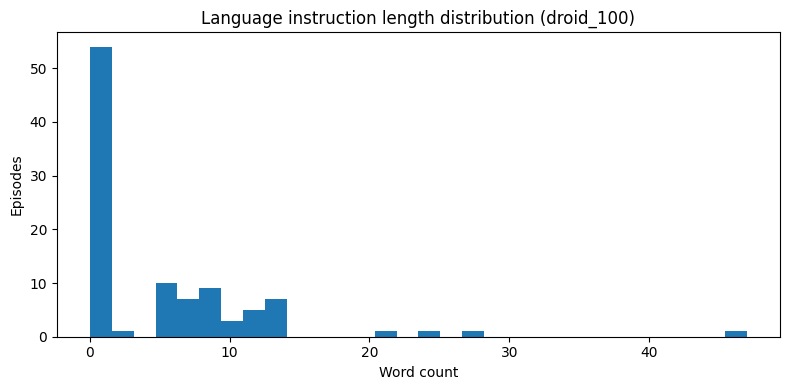

In [ ]:
# Distribution of instruction lengths
lens = [len(ep['language_instruction'].split()) for ep in instructions]
plt.figure(figsize=(8, 4))
plt.hist(lens, bins=30)
plt.xlabel('Word count')
plt.ylabel('Episodes')
plt.title('Language instruction length distribution (droid_100)')
plt.tight_layout()
plt.show()

## Part 2: Render Episode Visualizations

For each episode: 3 cameras side-by-side + control signal time series + prompt text.
Saves one MP4 per episode.

In [ ]:
# Reload without skip decoding for full image data
ds_full = builder.as_dataset(split='train')

n_episodes = builder.info.splits['train'].num_examples
print(f'{n_episodes} episodes available')

100 episodes available


In [ ]:
import random
random.seed(42)

N_RENDER = min(500, n_episodes)

# Shuffle with a fixed seed and take N — lazy, no RAM spike
ds_sampled = ds_full.shuffle(buffer_size=n_episodes, seed=42).take(N_RENDER)
print(f'Will render {N_RENDER} episodes')

Will render 100 episodes


In [ ]:
def extract_episode_data(episode):
    """Iterate over the nested steps dataset to collect numpy arrays."""
    ext1s, ext2s, wrists, actions, joint_poss, cart_poss, gripper_poss = [], [], [], [], [], [], []
    lang = lang2 = lang3 = ''

    for step in episode['steps']:
        if not lang:
            lang  = step['language_instruction'].numpy().decode('utf-8')
            lang2 = step['language_instruction_2'].numpy().decode('utf-8')
            lang3 = step['language_instruction_3'].numpy().decode('utf-8')
        ext1s.append(step['observation']['exterior_image_1_left'].numpy())
        ext2s.append(step['observation']['exterior_image_2_left'].numpy())
        wrists.append(step['observation']['wrist_image_left'].numpy())
        actions.append(step['action'].numpy())
        joint_poss.append(step['observation']['joint_position'].numpy())
        cart_poss.append(step['observation']['cartesian_position'].numpy())
        gripper_poss.append(step['observation']['gripper_position'].numpy())

    return {
        'lang': lang, 'lang2': lang2, 'lang3': lang3,
        'file_path': episode['episode_metadata']['file_path'].numpy().decode('utf-8'),
        'ext1':  np.stack(ext1s),
        'ext2':  np.stack(ext2s),
        'wrist': np.stack(wrists),
        'actions':     np.stack(actions),
        'joint_pos':   np.stack(joint_poss),
        'cart_pos':    np.stack(cart_poss),
        'gripper_pos': np.array(gripper_poss),
    }

In [ ]:
# Inspect one episode to verify shapes (takes first episode lazily)
ep_data = extract_episode_data(next(iter(ds_full)))
print('lang:', repr(ep_data['lang']))
print('ext1 shape:', ep_data['ext1'].shape)
print('wrist shape:', ep_data['wrist'].shape)
print('actions shape:', ep_data['actions'].shape)
print('num_steps:', ep_data['actions'].shape[0])

lang: 'Put the marker in the pot'
ext1 shape: (166, 180, 320, 3)
wrist shape: (166, 180, 320, 3)
actions shape: (166, 7)
num_steps: 166


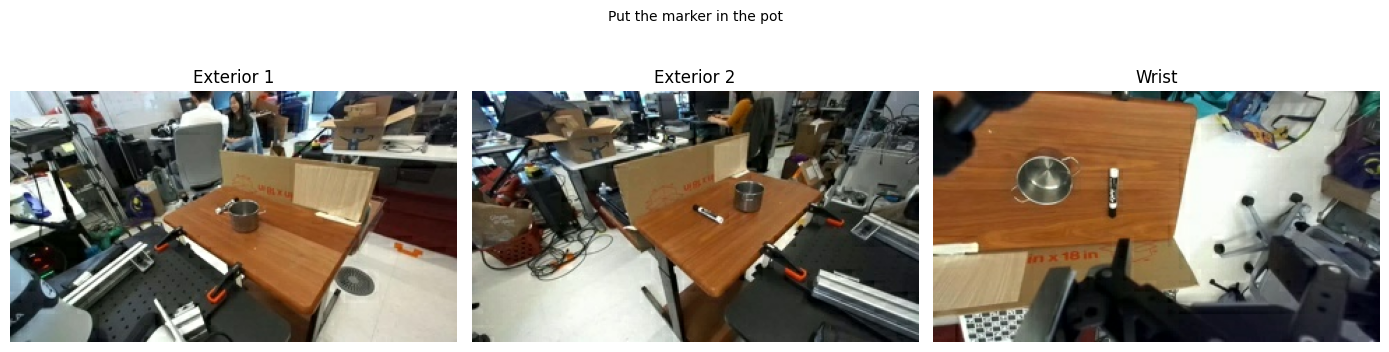

In [ ]:
# Sanity check: show frame 0 of all 3 cameras (reuses ep_data from above)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(ep_data['ext1'][0])
axes[0].set_title('Exterior 1')
axes[1].imshow(ep_data['ext2'][0])
axes[1].set_title('Exterior 2')
axes[2].imshow(ep_data['wrist'][0])
axes[2].set_title('Wrist')
fig.suptitle(ep_data['lang'], fontsize=10)
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import imageio

ACTION_LABELS = [
    'jvel_0', 'jvel_1', 'jvel_2', 'jvel_3', 'jvel_4', 'jvel_5', 'gripper_vel', 'act_7'
]

def render_episode_mp4(ep_data, out_path, fps=10):
    """Render an episode: 3 cameras (top) + action time series (bottom).
    Handles both 7-dim (TFDS/Part 2) and 8-dim (LeRobot/Part 3) action formats."""
    T_frames = ep_data['ext1'].shape[0]
    T_actions = ep_data['actions'].shape[0]
    T = min(T_frames, T_actions)

    n_act = ep_data['actions'].shape[1]
    act_labels = ACTION_LABELS[:n_act] if n_act <= len(ACTION_LABELS) else [f'act_{i}' for i in range(n_act)]

    lang = ep_data['lang'] or ep_data.get('lang2', '') or ep_data.get('lang3', '') or '(no instruction)'
    actions     = ep_data['actions'][:T]
    gripper_pos = ep_data['gripper_pos'][:T]
    t_axis = np.arange(T)

    fig = plt.figure(figsize=(16, 9.12), dpi=100)
    gs = gridspec.GridSpec(
        4, 4,
        left=0.06, right=0.98, top=0.92, bottom=0.06,
        hspace=0.5, wspace=0.35
    )

    ax_ext1  = fig.add_subplot(gs[:2, 0]); ax_ext1.axis('off');  ax_ext1.set_title('Exterior 1', fontsize=7)
    ax_ext2  = fig.add_subplot(gs[:2, 1]); ax_ext2.axis('off');  ax_ext2.set_title('Exterior 2', fontsize=7)
    ax_wrist = fig.add_subplot(gs[:2, 2]); ax_wrist.axis('off'); ax_wrist.set_title('Wrist', fontsize=7)

    ax_meta = fig.add_subplot(gs[:2, 3]); ax_meta.axis('off')
    meta_txt = str(ep_data.get('file_path', ep_data.get('episode_index', ''))).split('/')[-1]
    if ep_data.get('lang2'): meta_txt += f"\n\nAlt: {ep_data['lang2']}"
    ax_meta.text(0.05, 0.95, meta_txt, transform=ax_meta.transAxes,
                 fontsize=6, va='top', wrap=True, family='monospace')

    action_axes = [fig.add_subplot(gs[2 + r, c]) for r in range(2) for c in range(4)]
    for i in range(min(n_act, 7)):
        action_axes[i].plot(t_axis, actions[:, i], color='steelblue', lw=1)
        action_axes[i].set_title(act_labels[i], fontsize=7, pad=2)
        action_axes[i].tick_params(labelsize=5)
        action_axes[i].set_xlim(0, T - 1)
    action_axes[7].plot(t_axis, gripper_pos[:, 0], color='darkorange', lw=1)
    action_axes[7].set_title('gripper_pos', fontsize=7, pad=2)
    action_axes[7].tick_params(labelsize=5)
    action_axes[7].set_xlim(0, T - 1)

    fig.suptitle(lang, fontsize=9)
    cursor_lines = [ax.axvline(0, color='red', lw=1.2) for ax in action_axes]
    im1 = ax_ext1.imshow(ep_data['ext1'][0])
    im2 = ax_ext2.imshow(ep_data['ext2'][0])
    im3 = ax_wrist.imshow(ep_data['wrist'][0])

    # Pre-draw to get pixel size; ensure even height for h264
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    if h % 2 != 0:
        fig.set_size_inches(fig.get_size_inches()[0], (h + 1) / fig.dpi)
        fig.canvas.draw()
        w, h = fig.canvas.get_width_height()

    writer = imageio.get_writer(out_path, fps=fps, codec='libx264', quality=6)
    for t in range(T):
        im1.set_data(ep_data['ext1'][t])
        im2.set_data(ep_data['ext2'][t])
        im3.set_data(ep_data['wrist'][t])
        for line in cursor_lines:
            line.set_xdata([t, t])
        fig.canvas.draw()
        buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        buf = buf.reshape(h, w, 4)
        writer.append_data(buf[:, :, :3])  # drop alpha
    writer.close()
    plt.close(fig)

print('render_episode_mp4 defined')

In [ ]:
# Test render on one episode
test_ep_data = extract_episode_data(next(iter(ds_full)))
test_out = os.path.join(SAVE_DIR, 'test_episode_000.mp4')
render_episode_mp4(test_ep_data, test_out, fps=10)
print(f'Saved: {test_out}')

Saved: droid_renders/test_episode_000.mp4


In [ ]:
# Render all sampled episodes — iterates lazily, one episode in memory at a time
failed = []

for rank, episode in enumerate(tqdm(ds_sampled, total=N_RENDER)):
    out_path = os.path.join(SAVE_DIR, f'episode_{rank:04d}.mp4')
    if os.path.exists(out_path):
        continue
    try:
        ep_data = extract_episode_data(episode)
        render_episode_mp4(ep_data, out_path, fps=10)
    except Exception as e:
        print(f'Failed episode {rank}: {e}')
        failed.append(rank)

print(f'Done. {N_RENDER - len(failed)} rendered, {len(failed)} failed.')

100%|██████████| 100/100 [01:07<00:00,  1.48it/s]

Done. 100 rendered, 0 failed.


## Part 3: Download More Episodes from the Full DROID Dataset

Uses `aractingi/droid_1.0.1` — publicly available, no login required, 95k episodes.

Format: LeRobot v3 (parquet for data, mp4 per video chunk for cameras).
We download one chunk at a time (~1000 episodes per parquet file, video files shared across episodes).

In [5]:
import cv2
from huggingface_hub import hf_hub_download

REPO = 'aractingi/droid_1.0.1'
CAMERAS = [
    'observation.images.exterior_1_left',
    'observation.images.exterior_2_left',
    'observation.images.wrist_left',
]

# Download meta + data for chunk-000 (~1000 episodes, no login needed)
print('Downloading episode metadata...')
ep_meta = pd.read_parquet(hf_hub_download(REPO, 'meta/episodes/chunk-000/file-000.parquet', repo_type='dataset'))
print('Downloading data parquet...')
data_df  = pd.read_parquet(hf_hub_download(REPO, 'data/chunk-000/file-000.parquet', repo_type='dataset'))

n_episodes_full = ep_meta['episode_index'].nunique()
print(f'Episodes available in chunk-000: {n_episodes_full}')

Episodes available in chunk-000: 14153


In [6]:
def load_video_frames(vid_path, from_ts, to_ts, fps=15):
    """Extract frames between from_ts and to_ts (seconds) from a concatenated video file."""
    cap = cv2.VideoCapture(vid_path)
    cap.set(cv2.CAP_PROP_POS_MSEC, from_ts * 1000)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        pos = cap.get(cv2.CAP_PROP_POS_MSEC) / 1000.0
        if pos > to_ts + 1 / fps:
            break
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return np.stack(frames) if frames else np.zeros((1, 180, 320, 3), dtype=np.uint8)


# Cache for downloaded video files
_vid_cache = {}

def get_vid_path(chunk_idx, file_idx, cam):
    key = (chunk_idx, file_idx, cam)
    if key not in _vid_cache:
        remote = f'videos/{cam}/chunk-{chunk_idx:03d}/file-{file_idx:03d}.mp4'
        print(f'    downloading {remote}...', end=' ', flush=True)
        import time; t = time.time()
        _vid_cache[key] = hf_hub_download(REPO, remote, repo_type='dataset')
        print(f'{time.time()-t:.1f}s')
    return _vid_cache[key]


def extract_episode_full(ep_idx):
    ep = ep_meta[ep_meta['episode_index'] == ep_idx].iloc[0]
    ep_data = data_df[data_df['episode_index'] == ep_idx].reset_index(drop=True)

    lang  = ep_data.iloc[0]['language_instruction']  or ''
    lang2 = ep_data.iloc[0]['language_instruction_2'] or ''
    lang3 = ep_data.iloc[0]['language_instruction_3'] or ''

    cam_frames = {}
    for cam in CAMERAS:
        ci = int(ep[f'videos/{cam}/chunk_index'])
        fi = int(ep[f'videos/{cam}/file_index'])
        from_ts = ep[f'videos/{cam}/from_timestamp']
        to_ts   = ep[f'videos/{cam}/to_timestamp']
        vpath = get_vid_path(ci, fi, cam)
        cam_frames[cam] = load_video_frames(vpath, from_ts, to_ts)

    actions     = np.stack(ep_data['action'].tolist())
    gripper_pos = np.array(ep_data['observation.state.gripper_position'].tolist())

    return {
        'lang': lang, 'lang2': lang2, 'lang3': lang3,
        'episode_index': ep_idx,
        'ext1':  cam_frames[CAMERAS[0]],
        'ext2':  cam_frames[CAMERAS[1]],
        'wrist': cam_frames[CAMERAS[2]],
        'actions': actions,
        'gripper_pos': gripper_pos.reshape(-1, 1),
    }

print('extract_episode_full defined')

extract_episode_full defined


    downloading videos/observation.images.exterior_1_left/chunk-000/file-000.mp4... 0.2s
    downloading videos/observation.images.exterior_2_left/chunk-000/file-000.mp4... 0.2s
    downloading videos/observation.images.wrist_left/chunk-000/file-000.mp4... 0.2s
lang: 'Put the blue block in the green bowl'
ext1: (268, 180, 320, 3)
actions: (266, 8)


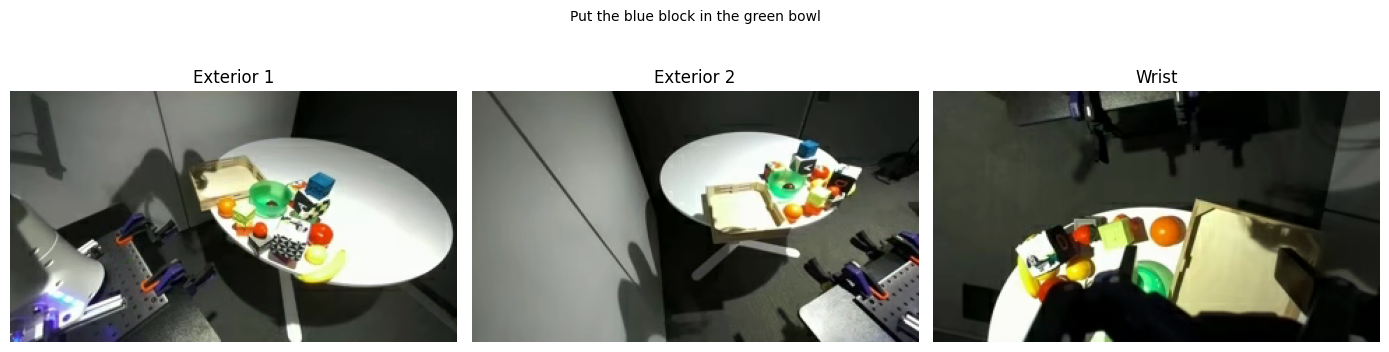

In [7]:
# Sanity check: load one episode and show cameras
ep_data_test = extract_episode_full(1)
print('lang:', repr(ep_data_test['lang']))
print('ext1:', ep_data_test['ext1'].shape)
print('actions:', ep_data_test['actions'].shape)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(ep_data_test['ext1'][0]);  axes[0].set_title('Exterior 1'); axes[0].axis('off')
axes[1].imshow(ep_data_test['ext2'][0]);  axes[1].set_title('Exterior 2'); axes[1].axis('off')
axes[2].imshow(ep_data_test['wrist'][0]); axes[2].set_title('Wrist');      axes[2].axis('off')
fig.suptitle(ep_data_test['lang'], fontsize=10)
plt.tight_layout()
plt.show()

In [8]:
# Extract all language instructions from chunk-000 (fast — no video, just parquet)
instructions_full = []
for ep_idx in data_df['episode_index'].unique():
    row = data_df[data_df['episode_index'] == ep_idx].iloc[0]
    instructions_full.append({
        'episode_index': int(ep_idx),
        'language_instruction': row['language_instruction'] or '',
        'language_instruction_2': row['language_instruction_2'] or '',
        'language_instruction_3': row['language_instruction_3'] or '',
    })

print(f'Extracted {len(instructions_full)} episode instructions')
unique_full = sorted(set(ep['language_instruction'] for ep in instructions_full if ep['language_instruction']))
print(f'Unique instructions: {len(unique_full)}')
for inst in unique_full[:20]:
    print(' -', repr(inst))

Extracted 1074 episode instructions
Unique instructions: 815
 - 'Attach the electric toothbrush to its charging port'
 - 'Change the position of the marker to face across the table'
 - 'Click the button on the mouse.'
 - 'Close the MacBook'
 - 'Close the black watering can'
 - 'Close the bottom drawer of the right cabinet'
 - 'Close the bottom drawer on the left'
 - 'Close the bottom left cabinet door'
 - 'Close the brown box.'
 - 'Close the cabinet drawer on the left'
 - 'Close the coffeemaker'
 - 'Close the curtain'
 - 'Close the door'
 - 'Close the doors to the two compartments'
 - 'Close the drawer'
 - 'Close the first top drawer'
 - 'Close the laptop'
 - 'Close the lid of the coffee maker'
 - 'Close the microwave door'
 - 'Close the open drawer'


In [9]:
def render_episode_cv2(ep_data, out_path, fps=15):
    """Fast episode render using cv2 — no matplotlib per-frame overhead."""
    T_frames = ep_data['ext1'].shape[0]
    T_actions = ep_data['actions'].shape[0]
    T = min(T_frames, T_actions)

    n_act = ep_data['actions'].shape[1]
    lang = ep_data['lang'] or ep_data.get('lang2', '') or ep_data.get('lang3', '') or '(no instruction)'

    actions = ep_data['actions'][:T]
    gripper_pos = ep_data['gripper_pos'][:T]
    t_axis = np.arange(T)

    # Pre-render action plots as a single static image (one matplotlib call)
    act_labels = ['act_0', 'act_1', 'act_2', 'act_3', 'act_4', 'act_5', 'act_6', 'grip_pos']
    fig, axes_arr = plt.subplots(2, 4, figsize=(16, 4), dpi=80)
    axes_flat = axes_arr.flatten()
    for i in range(min(n_act, 7)):
        axes_flat[i].plot(t_axis, actions[:, i], color='steelblue', lw=1)
        axes_flat[i].set_title(act_labels[i], fontsize=8)
        axes_flat[i].tick_params(labelsize=5)
        axes_flat[i].set_xlim(0, T - 1)
    axes_flat[7].plot(t_axis, gripper_pos[:, 0], color='darkorange', lw=1)
    axes_flat[7].set_title('grip_pos', fontsize=8)
    axes_flat[7].tick_params(labelsize=5)
    axes_flat[7].set_xlim(0, T - 1)
    plt.tight_layout()
    fig.canvas.draw()
    plot_w, plot_h = fig.canvas.get_width_height()
    plot_img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8).reshape(plot_h, plot_w, 4)[:, :, :3].copy()

    # Get cursor x-ranges from subplot positions before closing fig
    cursor_info = []
    for i in range(8):
        bbox = axes_flat[i].get_position()
        x_left = int(bbox.x0 * plot_w)
        x_right = int(bbox.x1 * plot_w)
        y_top = int((1 - bbox.y0) * plot_h)
        y_bot = int((1 - bbox.y1) * plot_h)
        cursor_info.append((x_left, x_right, y_bot, y_top))
    plt.close(fig)

    # Camera frame dimensions
    cam_h, cam_w = ep_data['ext1'].shape[1], ep_data['ext1'].shape[2]
    cam_disp_w = plot_w // 3
    cam_disp_h = int(cam_h * cam_disp_w / cam_w)
    frame_h = cam_disp_h + 40 + plot_h
    frame_w = plot_w
    frame_h = frame_h + (frame_h % 2)
    frame_w = frame_w + (frame_w % 2)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(out_path, fourcc, fps, (frame_w, frame_h))

    for t in range(T):
        frame = np.zeros((frame_h, frame_w, 3), dtype=np.uint8)

        for ci, cam_key in enumerate(['ext1', 'ext2', 'wrist']):
            img = cv2.resize(ep_data[cam_key][t], (cam_disp_w, cam_disp_h))
            x_off = ci * cam_disp_w
            frame[0:cam_disp_h, x_off:x_off+cam_disp_w] = img[:, :, ::-1]

        cv2.putText(frame, lang[:100], (10, cam_disp_h + 25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 1, cv2.LINE_AA)

        plot_frame = plot_img.copy()
        frac = t / max(T - 1, 1)
        for (x_left, x_right, y_bot, y_top) in cursor_info:
            cx = int(x_left + frac * (x_right - x_left))
            cv2.line(plot_frame, (cx, y_bot), (cx, y_top), (0, 0, 255), 2)

        y_off = cam_disp_h + 40
        frame[y_off:y_off+plot_h, 0:plot_w] = plot_frame[:, :, ::-1]

        cv2.putText(frame, f'{t+1}/{T}', (frame_w - 100, 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1, cv2.LINE_AA)

        writer.write(frame)

    writer.release()

print('render_episode_cv2 defined')

render_episode_cv2 defined


In [10]:
# Render 500 episodes using fast cv2 renderer
# Only sample from episodes that exist in data_df
import random, time
random.seed(42)

valid_ep_indices = sorted(data_df['episode_index'].unique().tolist())
print(f'{len(valid_ep_indices)} episodes with data in chunk-000')

N_RENDER_FULL = min(500, len(valid_ep_indices))
sampled_eps = random.sample(valid_ep_indices, N_RENDER_FULL)
print(f'Will render {N_RENDER_FULL} episodes')

failed_full = []
for rank, ep_idx in enumerate(sampled_eps):
    out_path = os.path.join(SAVE_DIR, f'droid_full_ep_{rank:04d}.mp4')
    if os.path.exists(out_path):
        continue

    t0 = time.time()
    print(f'[{rank+1}/{N_RENDER_FULL}] ep={ep_idx}', end=' ', flush=True)
    try:
        ep_data = extract_episode_full(ep_idx)
        ep_data['file_path'] = f'ep_{ep_idx}'
        T = min(ep_data['ext1'].shape[0], ep_data['actions'].shape[0])
        print(f'{T}fr lang={repr(ep_data["lang"][:40])}', end=' ', flush=True)
        render_episode_cv2(ep_data, out_path, fps=15)
        print(f'ok ({time.time()-t0:.1f}s)')
    except Exception as e:
        print(f'FAILED: {e}')
        failed_full.append(ep_idx)

print(f'\nDone. {N_RENDER_FULL - len(failed_full)} rendered, {len(failed_full)} failed.')

1074 episodes with data in chunk-000
Will render 500 episodes
[1/500] ep=228 241fr lang='Remove the knife from the cup' ok (2.1s)
[2/500] ep=51 202fr lang='Put the towel on the seat of the chair' ok (1.4s)
[3/500] ep=563     downloading videos/observation.images.exterior_1_left/chunk-000/file-001.mp4... 0.2s
    downloading videos/observation.images.exterior_2_left/chunk-000/file-001.mp4... 0.3s
    downloading videos/observation.images.wrist_left/chunk-000/file-001.mp4... 0.2s
600fr lang='Pour the coffee beans from the white pla' ok (4.8s)
[4/500] ep=501 97fr lang='' ok (1.1s)
[5/500] ep=457 106fr lang='Press a button on the coffee maker' ok (0.8s)
[6/500] ep=285 146fr lang='Turn the coffee machine by pushing the h' ok (1.0s)
[7/500] ep=209 260fr lang='Move the takeaway pack to the top right' ok (1.7s)
[8/500] ep=178 490fr lang='Remove the plate from the oven the use t' ok (3.0s)
[9/500] ep=864     downloading videos/observation.images.exterior_1_left/chunk-000/file-002.mp4... 0.2s
  